In [1]:
import numpy as np
import pandas as pd
import re
import string
import matplotlib.pyplot as plt

# **Preparing The Dataset**

In [3]:
columns = ["comment","sentiment"]
df = pd.read_csv("comments_data.csv", names=columns, header=0)
print("Dataframe shape : ",df.shape)
df.head()

Dataframe shape :  (18408, 2)


,comment,sentiment
0,lets not forget that apple pay in 2014 require...,neutral
1,here in nz 50 of retailers don’t even have con...,negative
2,i will forever acknowledge this channel with t...,positive
3,whenever i go to a place that doesn’t take app...,negative
4,apple pay is so convenient secure and easy to ...,positive


# **Cleaning The DataSet**

In [4]:
def clean_text(text):
  if not isinstance(text, str):
    return

  text = text.lower()
  # Removing URLs from the text
  text = re.sub(r"http\S+|www\S+", "", text)

  # Removing numbers from the text
  text = re.sub(r"\d+", "", text)

  # Removing punctuation
  text = text.translate(str.maketrans("", "", string.punctuation))

  # Removing extra spaces
  text = text.strip()

  return text

In [5]:
df["clean_comment"] = df["comment"].apply(clean_text)
df.head()

,comment,sentiment,clean_comment
0,lets not forget that apple pay in 2014 require...,neutral,lets not forget that apple pay in required a ...
1,here in nz 50 of retailers don’t even have con...,negative,here in nz of retailers don’t even have conta...
2,i will forever acknowledge this channel with t...,positive,i will forever acknowledge this channel with t...
3,whenever i go to a place that doesn’t take app...,negative,whenever i go to a place that doesn’t take app...
4,apple pay is so convenient secure and easy to ...,positive,apple pay is so convenient secure and easy to ...


In [6]:
# Removing rows with missing values
df = df.dropna(subset=["sentiment","clean_comment"])

# Data frame shape after removing the rows with missing values
print("Dataframe shape : ",df.shape)

Dataframe shape :  (18364, 3)


# **Class Distribution of the Dataset**

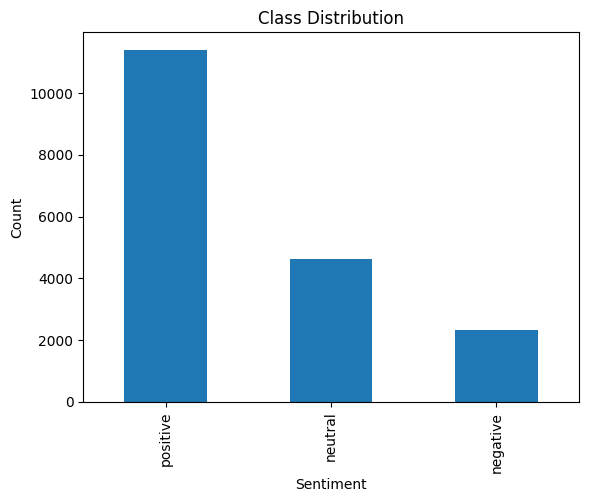

In [7]:
df["sentiment"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

# **Applying SMOTE (Since dataset is imbalanced)**

In [11]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter

In [9]:
X = df["clean_comment"]
y = df["sentiment"]

In [10]:
# Converting text to numerical form (Since cannot apply SMOTE directly on text)
vectorizer = TfidfVectorizer(max_features=5000)
X_vectorized = vectorizer.fit_transform(X)

In [12]:
# Splitting the dataset before SMOTE
X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized, y, test_size=0.2, random_state=42
)

In [13]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [14]:
print("Before SMOTE : ", Counter(y_train))
print("After SMOTE : ",Counter(y_train_resampled))

Before SMOTE :  Counter({'positive': 9082, 'neutral': 3713, 'negative': 1896})
After SMOTE :  Counter({'positive': 9082, 'negative': 9082, 'neutral': 9082})


# **Model Creation and Training**

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

In [21]:
# Initializing the model
random_forest_model = RandomForestClassifier(
    n_estimators=200, random_state=42, class_weight="balanced"
)

# Train model using SMOTE data
random_forest_model.fit(X_train_resampled, y_train_resampled)

y_pred = random_forest_model.predict(X_test)

In [22]:
# Accuracy of Random Forest Model for the dataset
print("Accuracy : ", accuracy_score(y_test, y_pred))

# Classification Report
print(classification_report(y_test, y_pred))

Accuracy :  0.7225701061802341
              precision    recall  f1-score   support

    negative       0.41      0.27      0.32       441
     neutral       0.67      0.48      0.56       912
    positive       0.77      0.90      0.83      2320

    accuracy                           0.72      3673
   macro avg       0.62      0.55      0.57      3673
weighted avg       0.70      0.72      0.70      3673

